In [69]:
#Tracker Data Analysis
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams.update({'font.size':12, 'font.family':'serif'}) #Setting fonts
plt.rcParams['text.usetex'] = False

import string #For figure labels


def plotderive(file, n=0, m=-1): #n is number of elements to be skipped from the beginning index.
    t = []
    y = []
    for i in file:
        t.append(i[0])
        y.append(i[2])
    
    yfull = y - y[0]
    y = np.array(yfull[n:m])
    t = np.array(t[n:m])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.scatter(t, y, c='firebrick', label='Data', s=30)
    a, b, c = np.polyfit(t, y, deg=2)
    y_fit = a*t**2 + b*t + c
    eqn_y = f"$y = {a:.3f}t^2 + {b:.3f}t + {c:.3f}$"
    ax1.plot(t, y_fit, c='darkblue', label=eqn_y)
    
    ax1.grid()
    ax1.legend()
    ax1.set_xlabel("time (s)")
    ax1.set_ylabel(r"y ($m$)")
    
    v_fit = 2*a*t + b
    eqn_v = f"$V = {2*a:.3f}t + {b:.3f}$"
    ax2.scatter(t, v_fit, c='darkblue', label=eqn_v, s=30)
    
    ax2.grid()
    ax2.set_xlabel("time (s)")
    ax2.set_ylabel(r"V ($ms^{-1}$)")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


import glob

def plot_all_trials_derive_normalized(base_path="../Freefall_PartA/mass M2/",
                                      prefix="m2_trial",
                                      n=0, m=-1, num_trials=25):
    """
    Plots all trials with time normalized so the drop starts at t=0.
    Left: y(t)
    Right: v(t) derived from quadratic fits
    Also computes g from the slope of each v(t) graph (linear fit across full range).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    cmap = plt.cm.get_cmap('tab20', num_trials)
    colors = [cmap(i % cmap.N) for i in range(num_trials)]

    g_values = []

    for i in range(1, num_trials + 1):
        filepath = f"{base_path}{prefix}{i}.txt"
        try:
            data = np.loadtxt(filepath, delimiter=',', skiprows=2)
            if data.ndim < 2 or data.shape[1] < 3:
                print(f"Skipping Trial {i}: insufficient data")
                continue

            t = data[:, 0]
            y = data[:, 2]
            y = y - y[0]

            # Detect approximate drop start
            dy_dt = np.gradient(y, t)
            drop_index = np.argmax(dy_dt < -0.1)
            if drop_index == 0 or drop_index > len(t) - 10:
                drop_index = n  # fallback

            # Shift so drop starts at t=0
            t_shifted = t - t[drop_index]

            # Slice region for plotting
            t_plot = t_shifted[n:m] if m != -1 else t_shifted[n:]
            y_plot = y[n:m] if m != -1 else y[n:]

            # Skip invalid data
            if len(t_plot) < 5 or np.any(np.isnan(t_plot)) or np.any(np.isnan(y_plot)):
                print(f"Skipping Trial {i}: invalid data slice")
                continue

            # Quadratic fit
            a, b, c = np.polyfit(t_plot, y_plot, 2)
            y_fit = a * t_plot**2 + b * t_plot + c
            v_fit = 2 * a * t_plot + b

            color = colors[i - 1]

            # --- Position plot ---
            ax1.scatter(t_plot, y_plot, s=10, color=color, alpha=0.9)
            ax1.plot(t_plot, y_fit, lw=1, color=color, label=f"Trial {i}")

            # --- Velocity plot ---
            ax2.scatter(t_plot, v_fit, s=10, color=color, alpha=0.9)
            ax2.plot(t_plot, v_fit, lw=1, color=color, label=f"Trial {i}")

            # --- Get g from slope of v(t) ---
            g, intercept = np.polyfit(t_plot, v_fit, 1)
            g_values.append(g)

        except Exception as e:
            print(f"Skipping Trial {i}: {e}")

    # --- Formatting ---
    ax1.set_xlabel("Time (s, normalized to drop start)")
    ax1.set_ylabel(r"y ($m$)")
    ax1.set_title("y(t) — All Trials Aligned")
    ax1.grid(True)
    ax1.legend(fontsize=8, loc="best", ncol=2)

    ax2.set_xlabel("Time (s, normalized to drop start)")
    ax2.set_ylabel(r"v ($m/s$)")
    ax2.set_title("v(t) — Derived from Quadratic Fits")
    ax2.grid(True)
    ax2.legend(fontsize=8, loc="best", ncol=2)

    plt.tight_layout()
    plt.show()

    # --- Output summary of g values ---
    if len(g_values) > 0:
        mean_g = np.mean(g_values)
        std_g = np.std(g_values)
        print("\n--- Gravitational Acceleration Results ---")
        for i, g in enumerate(g_values, 1):
            print(f"Trial {i:2d}: g = {g:6.4f} m/s²")
        print(f"\nMean g = {mean_g:.4f} ± {std_g:.4f} m/s² (std)")
    else:
        print("No valid g values computed.")


# Mass 1

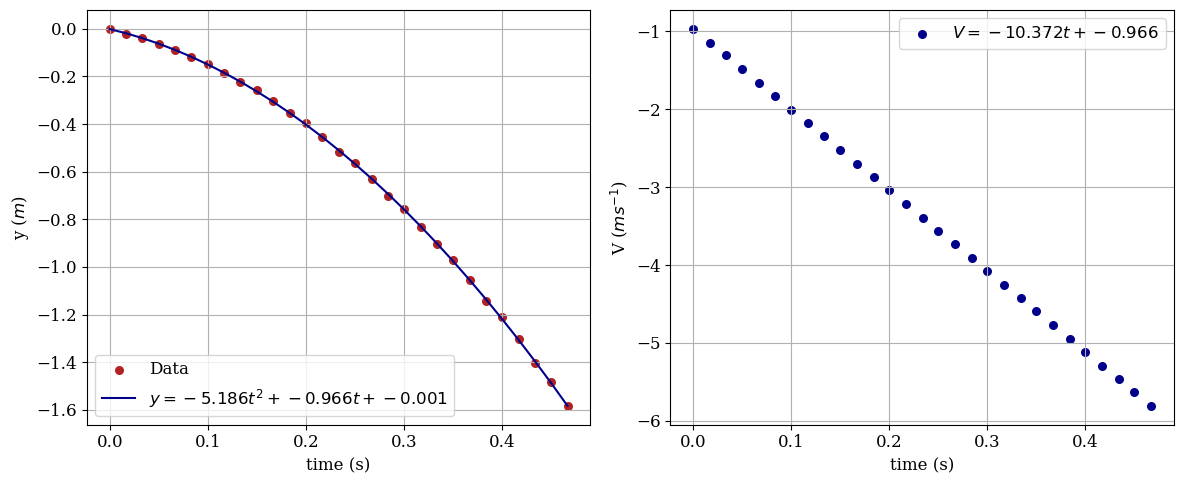

In [3]:
#TRIAL 1
file_t1 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial1.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t1)

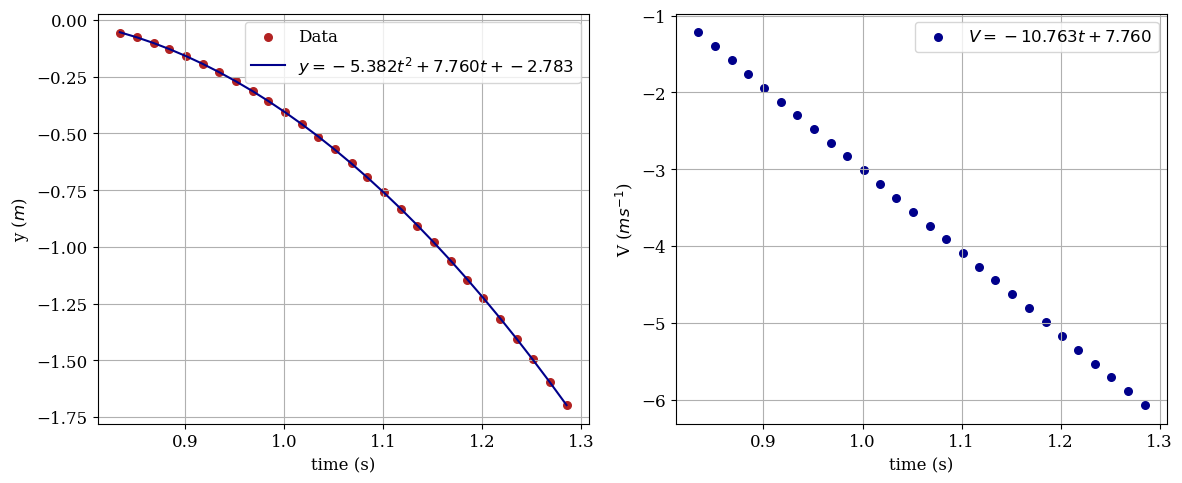

In [4]:
#TRIAL 2
file_t2 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial2.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t2, n=50)

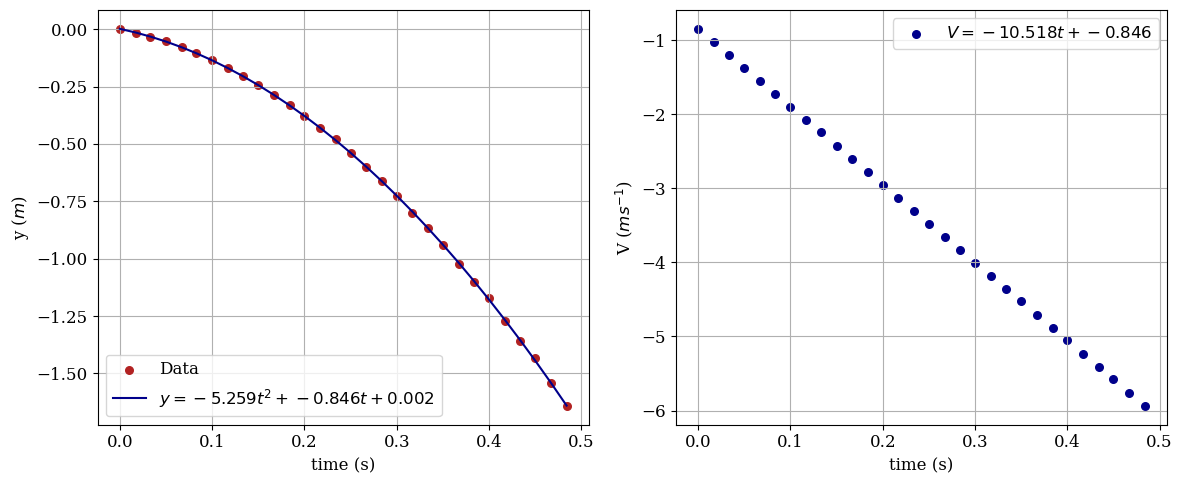

In [5]:
#TRIAL 3
file_t3 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial3.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t3)

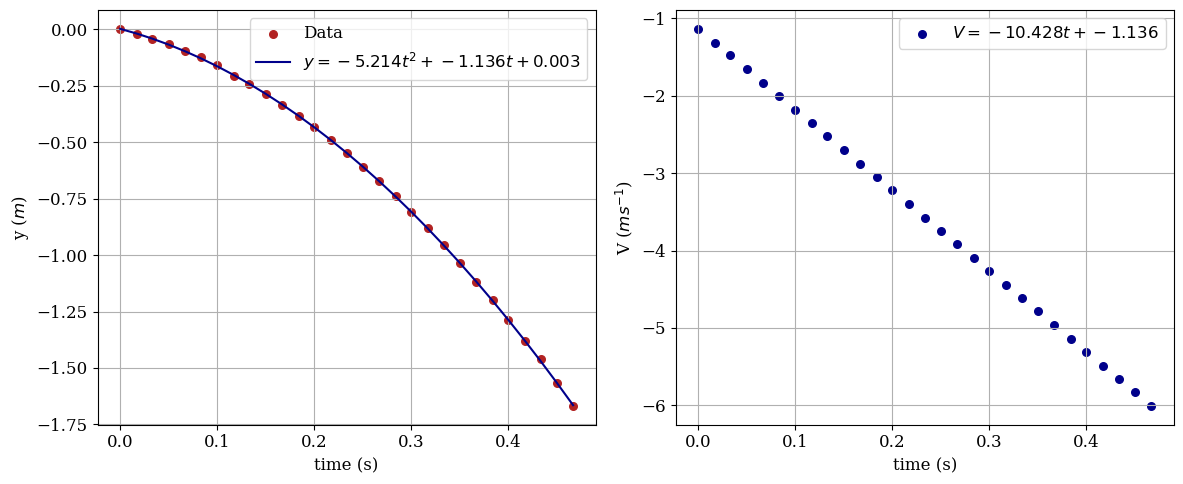

In [6]:
#TRIAL 4
file_t4 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial4.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t4)

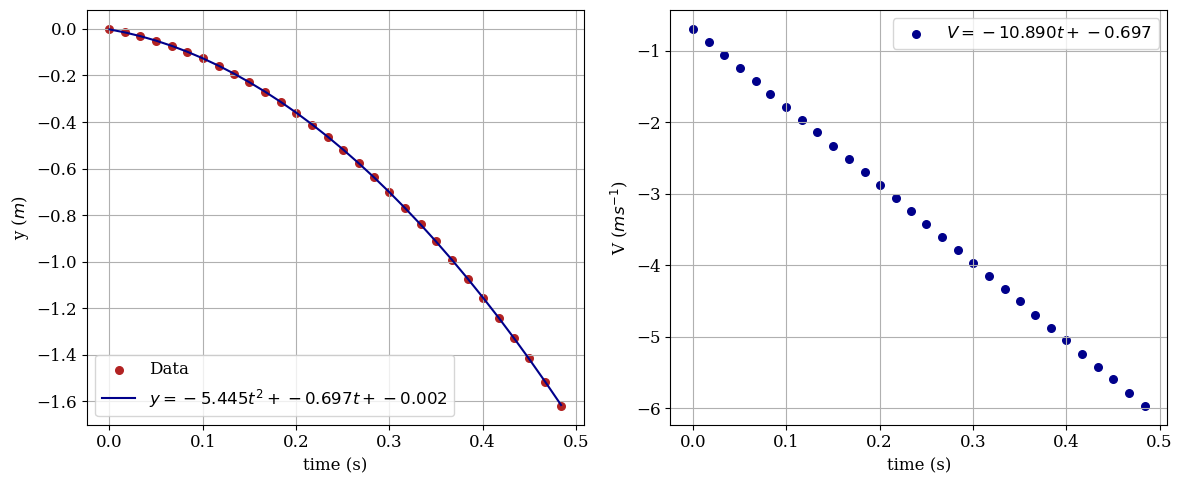

In [7]:
#TRIAL 5
file_t5 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial5.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t5)

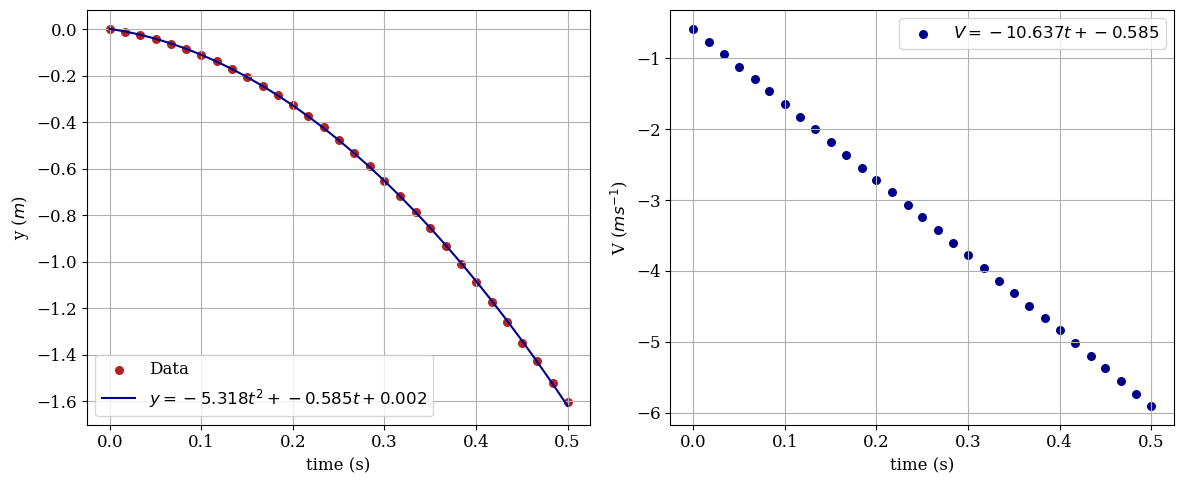

In [8]:
#TRIAL 6
file_t6 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial6.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t6)

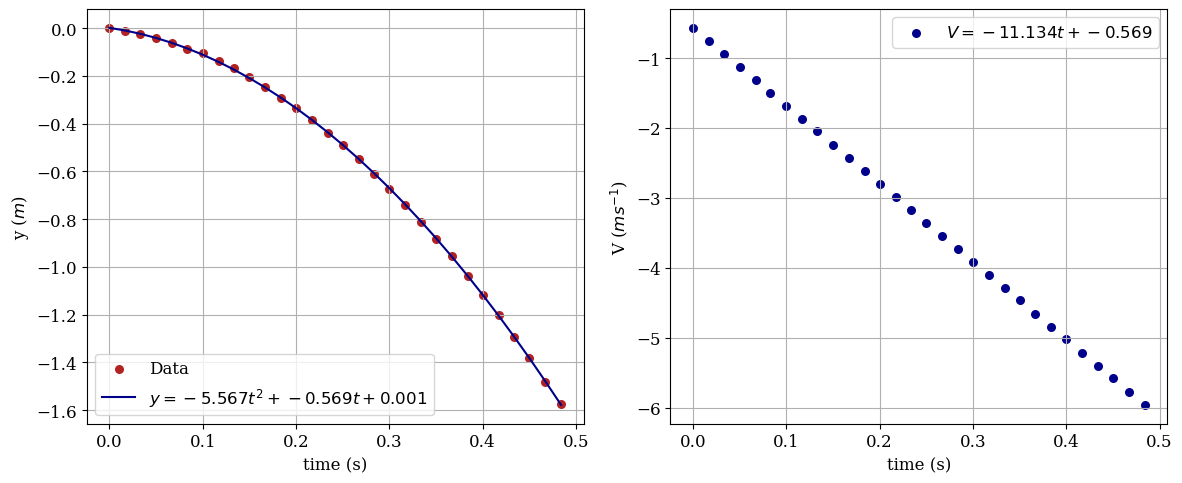

In [9]:
#TRIAL 7
file_t7 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial7.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t7)

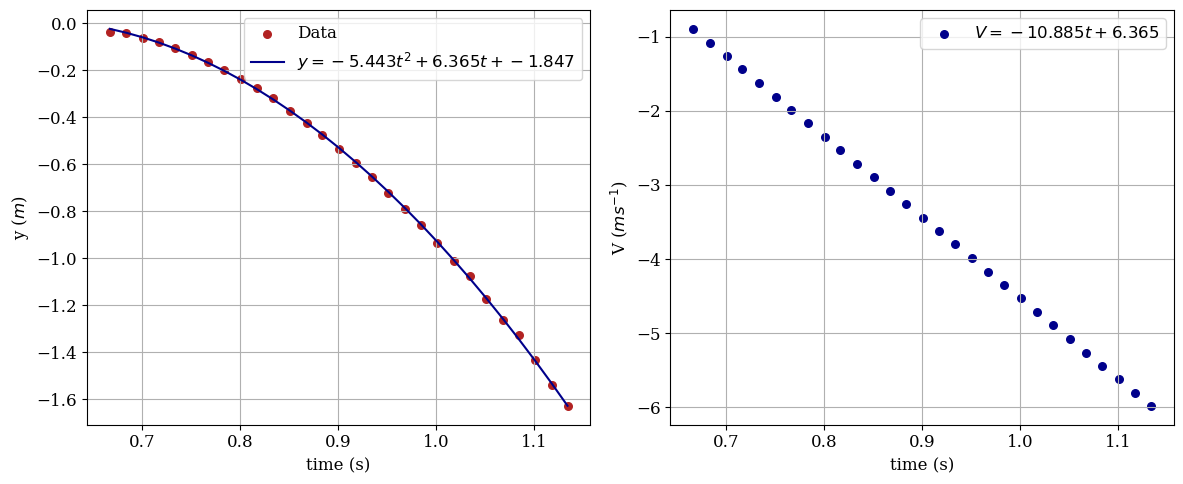

In [10]:
#TRIAL 8
file_t8 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial8.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t8, 40)

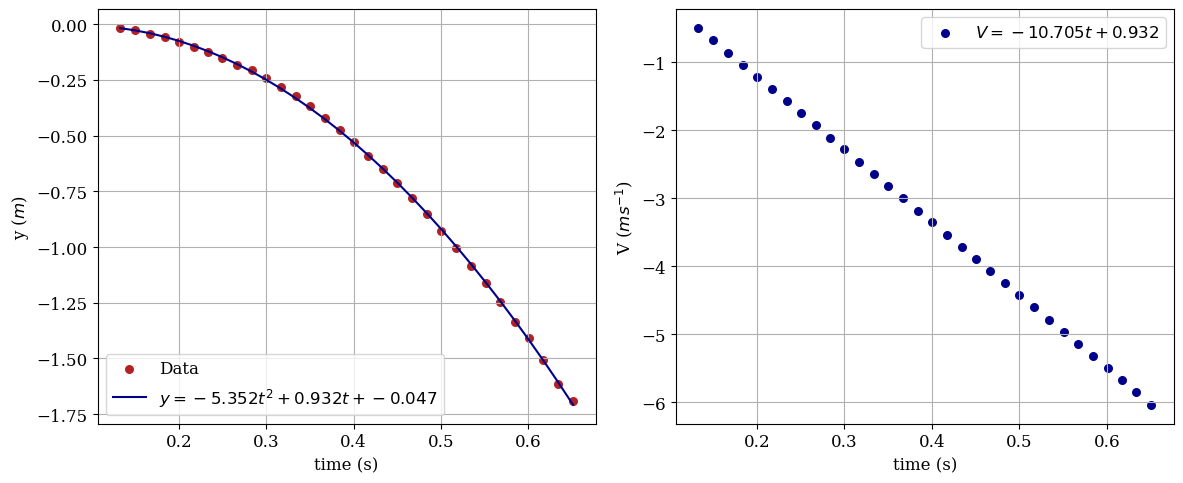

In [11]:
#TRIAL 9
file_t9 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial9.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t9, 8)

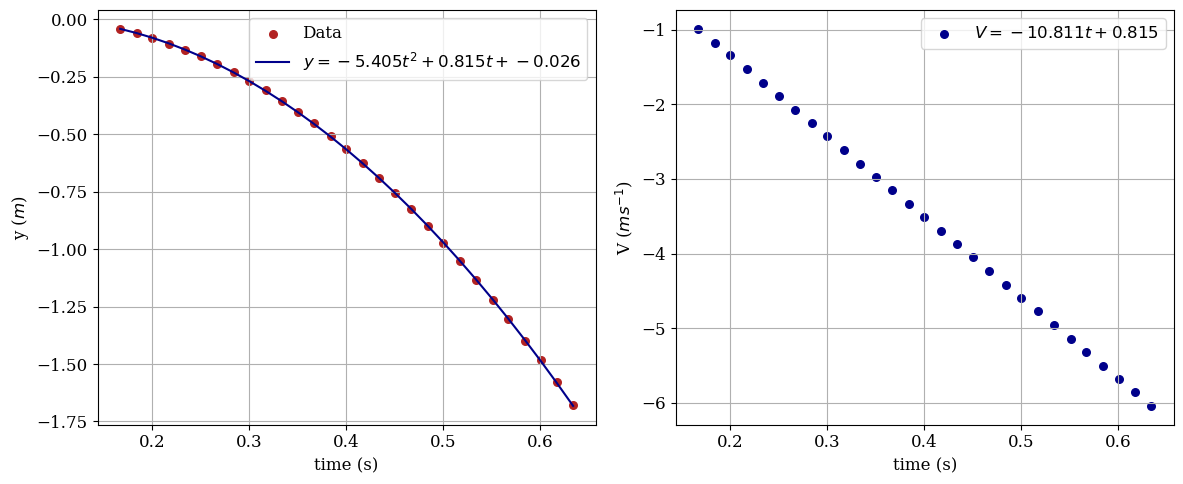

In [12]:
#TRIAL 10
file_t10 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial10.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t10, 10)

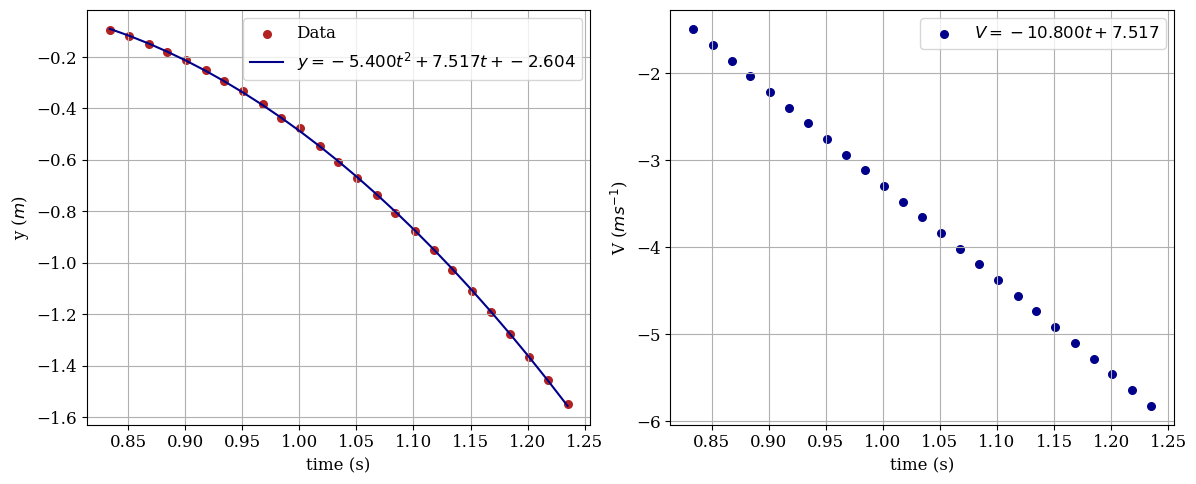

In [13]:
#TRIAL 11
file_t11 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial11.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t11, 50)

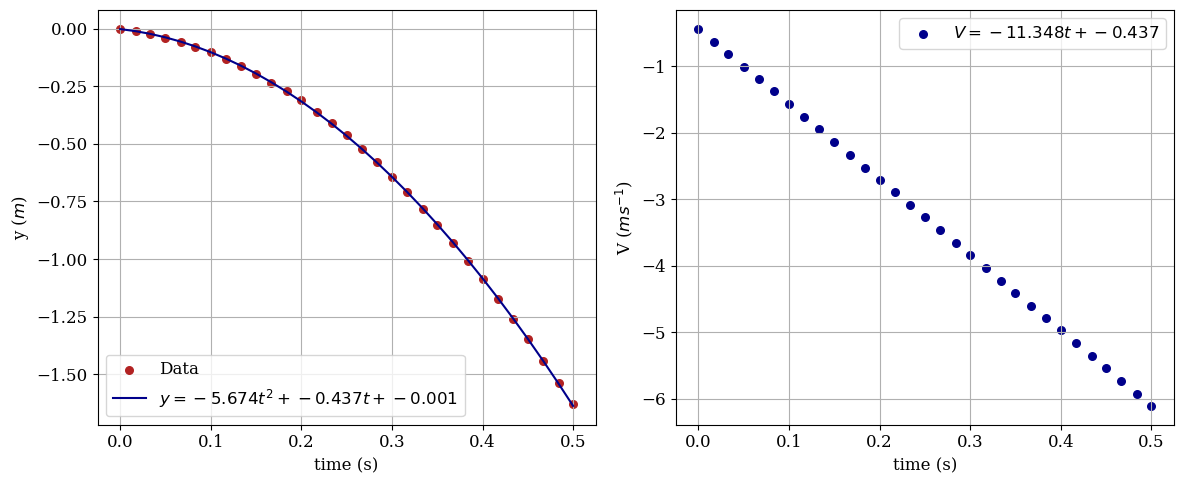

In [14]:
#TRIAL 12
file_t12 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial12.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t12)

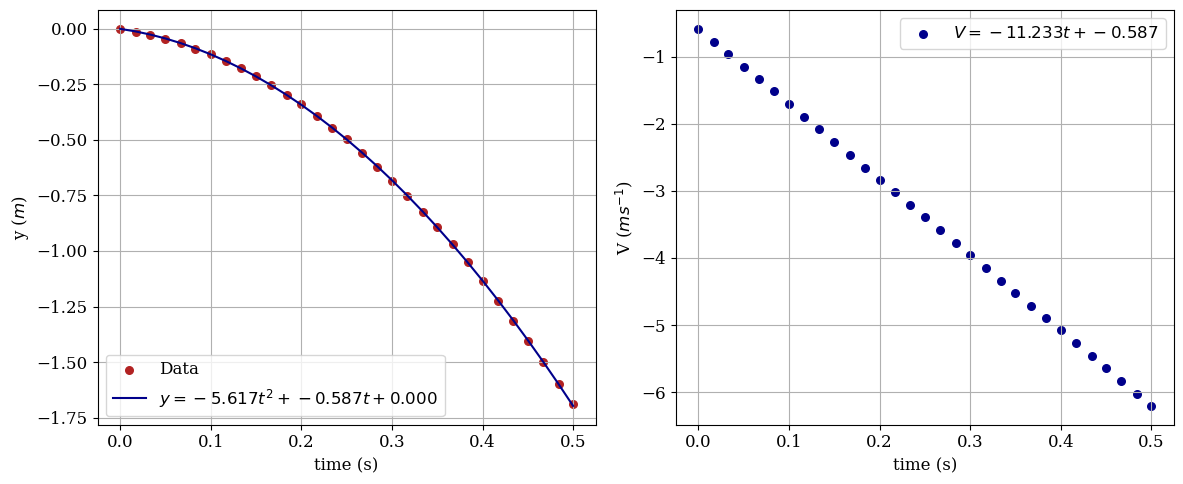

In [15]:
#TRIAL 13
file_t13 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial13.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t13)

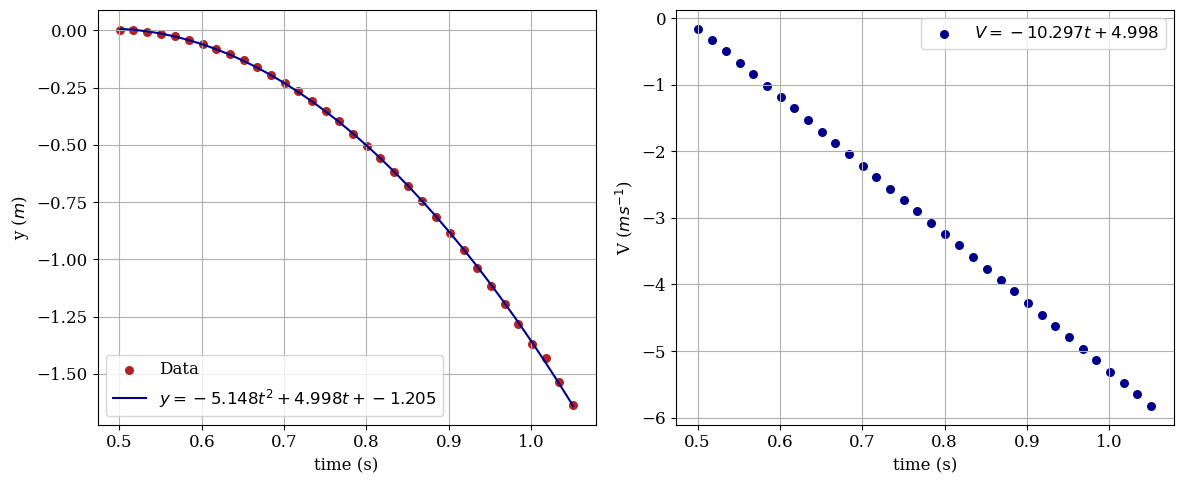

In [16]:
#TRIAL 14
file_t14 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial14.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t14, 30)

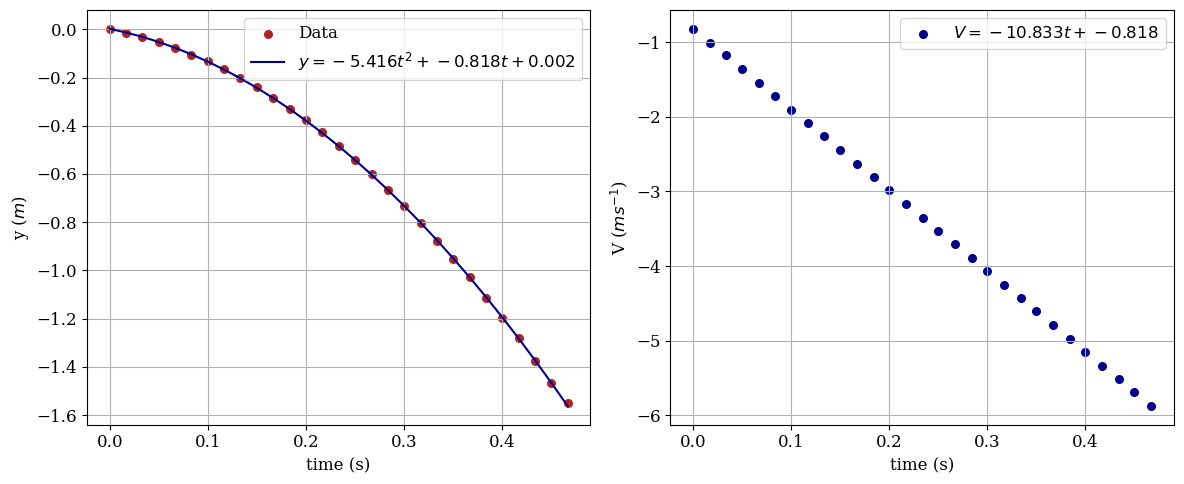

In [17]:
#TRIAL 15
file_t15 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial15.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t15)

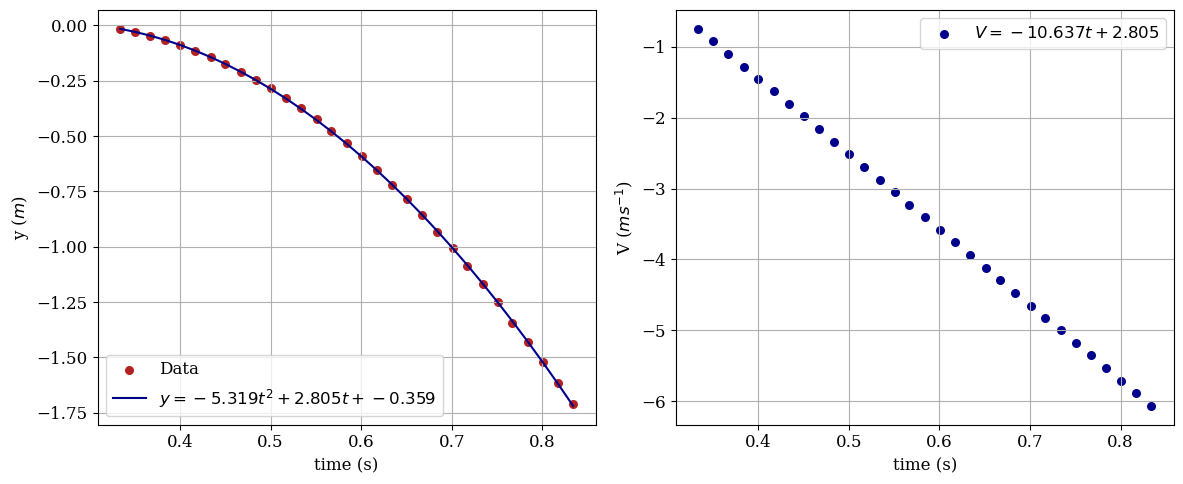

In [18]:
#TRIAL 16
file_t16 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial16.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t16, 20)

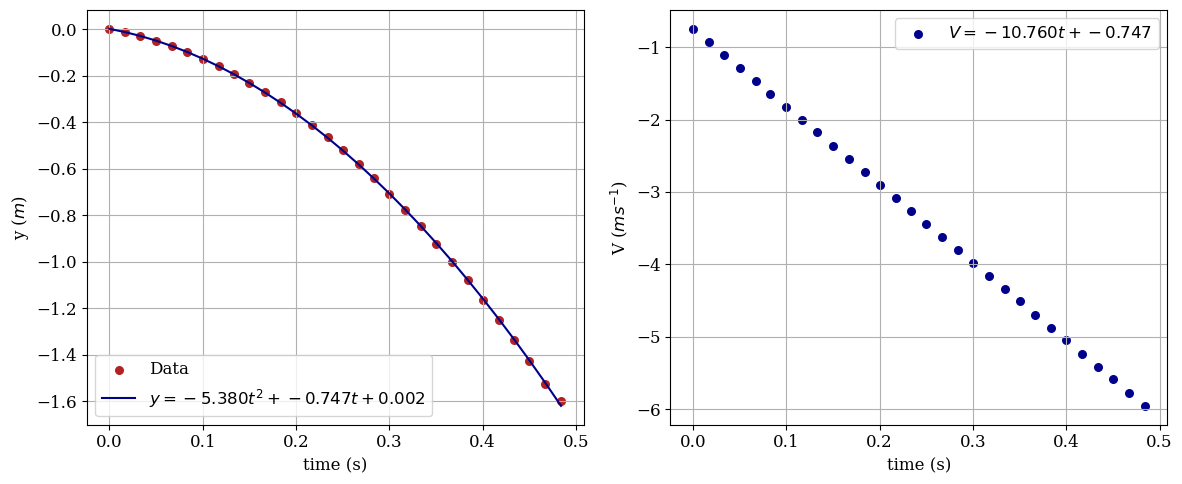

In [19]:
#TRIAL 17
file_t17 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial17.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t17)

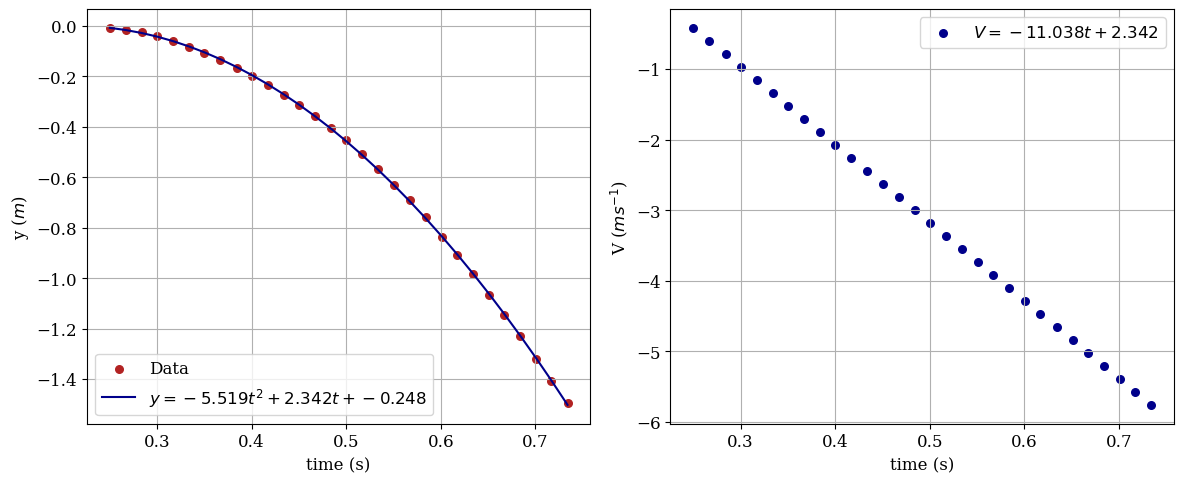

In [20]:
#TRIAL 18
file_t18 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial18.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t18, 15)

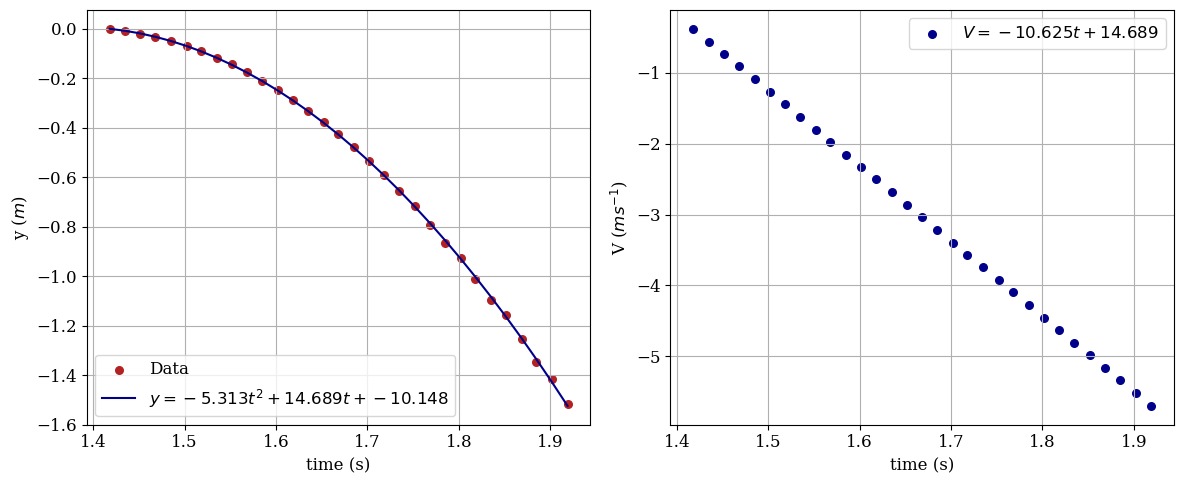

In [21]:
#TRIAL 19
file_t19 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial19.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t19, 85)

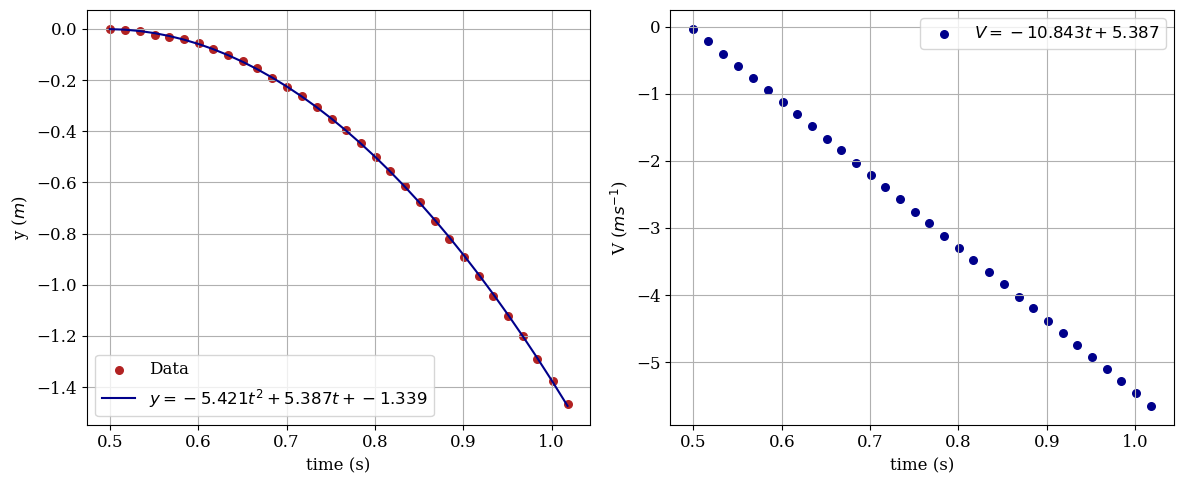

In [22]:
#TRIAL 20
file_t20 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial20.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t20, 30)

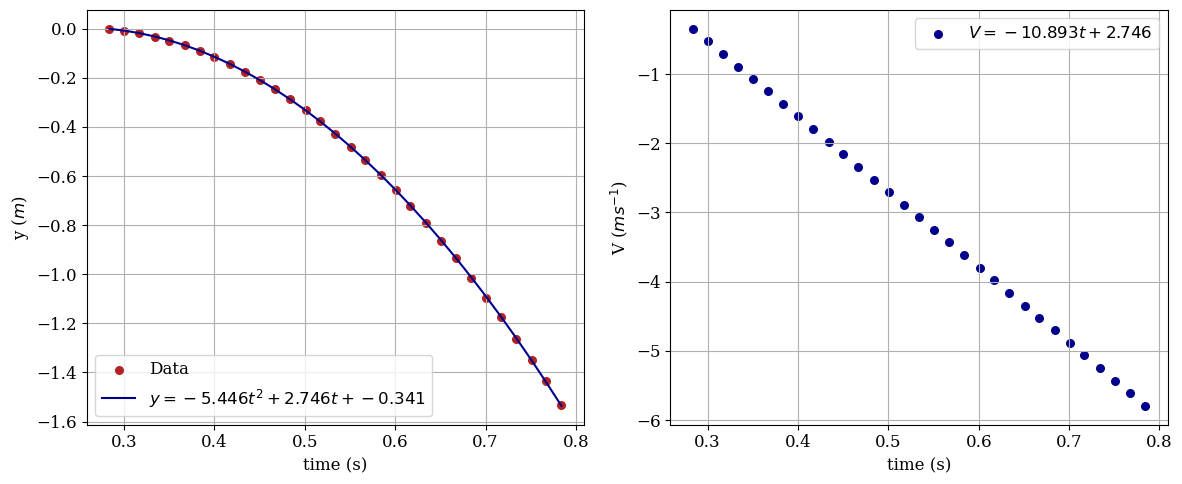

In [23]:
#TRIAL 21
file_t21 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial21.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t21, 17)

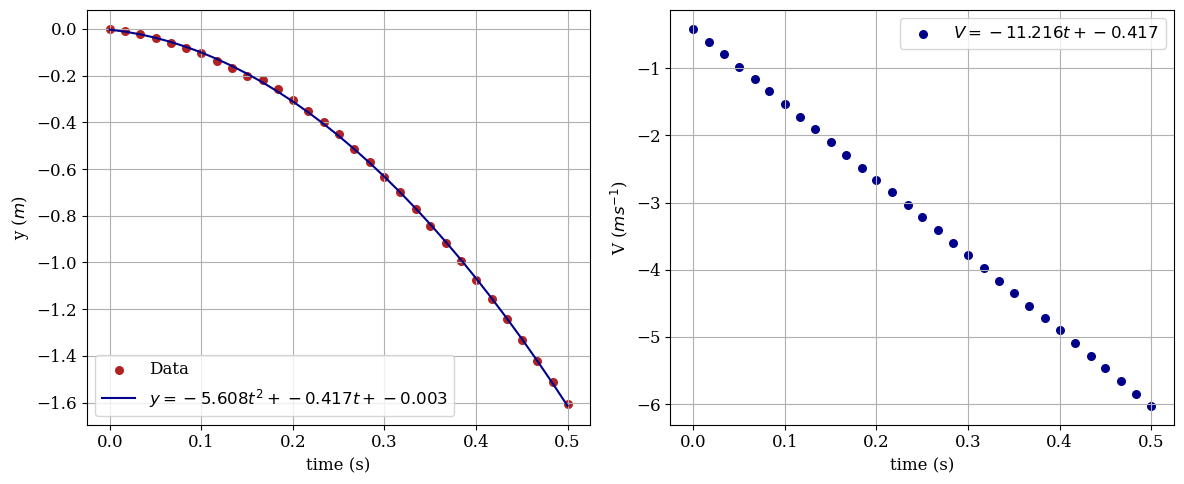

In [24]:
#TRIAL 22
file_t22 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial22.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t22)

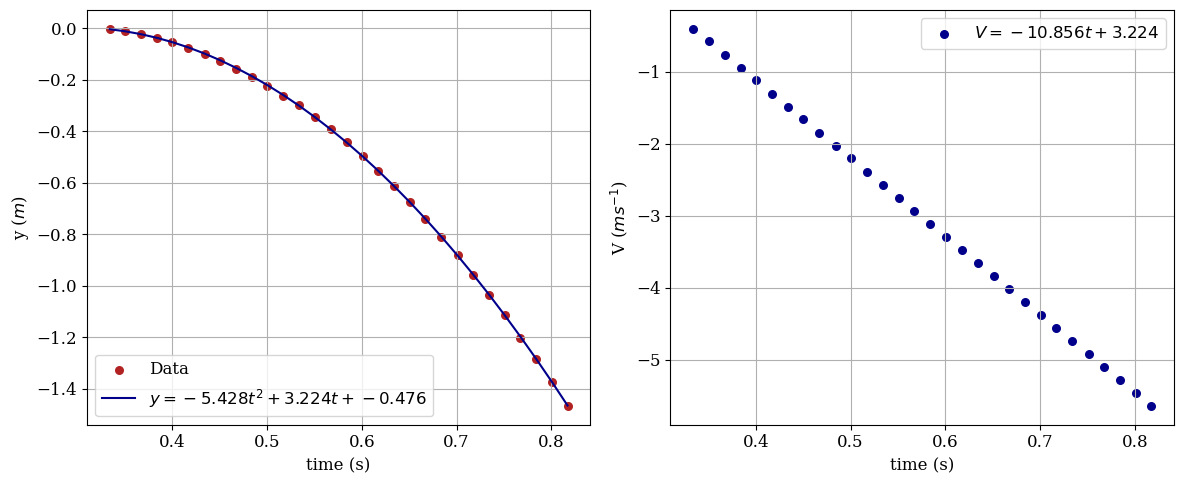

In [25]:
#TRIAL 23
file_t23 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial23.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t23, 20)

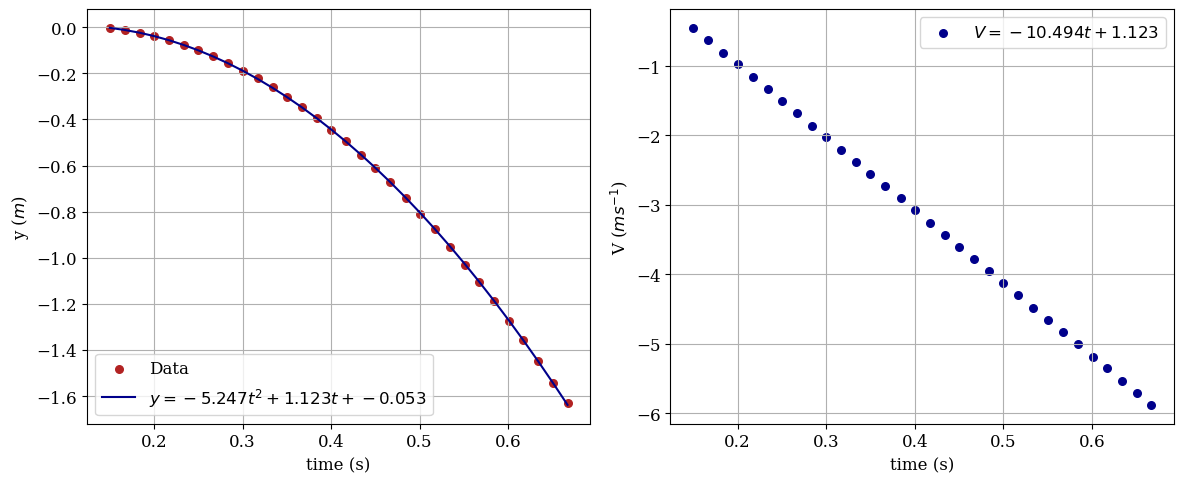

In [26]:
#TRIAL 24
file_t24 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial24.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t24, 9)

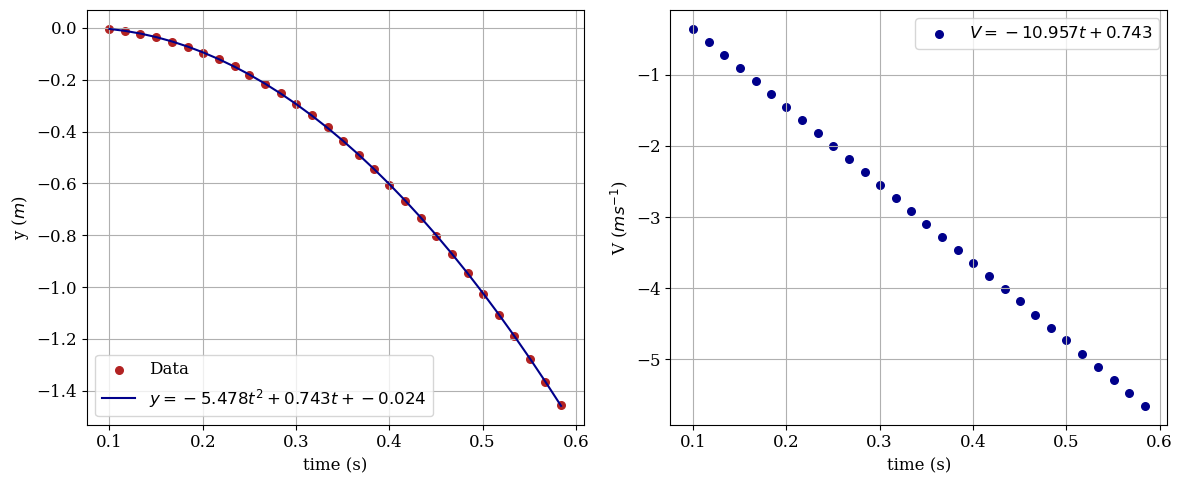

In [27]:
#TRIAL 25
file_t25 = np.loadtxt("../Freefall_PartA/mass M1/m1_trial25.txt", delimiter=',', skiprows=2)
# print(file_t1)
plotderive(file_t25, 6)

C:\Users\abhim\AppData\Local\Temp\ipykernel_20368\2027722420.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', num_trials)


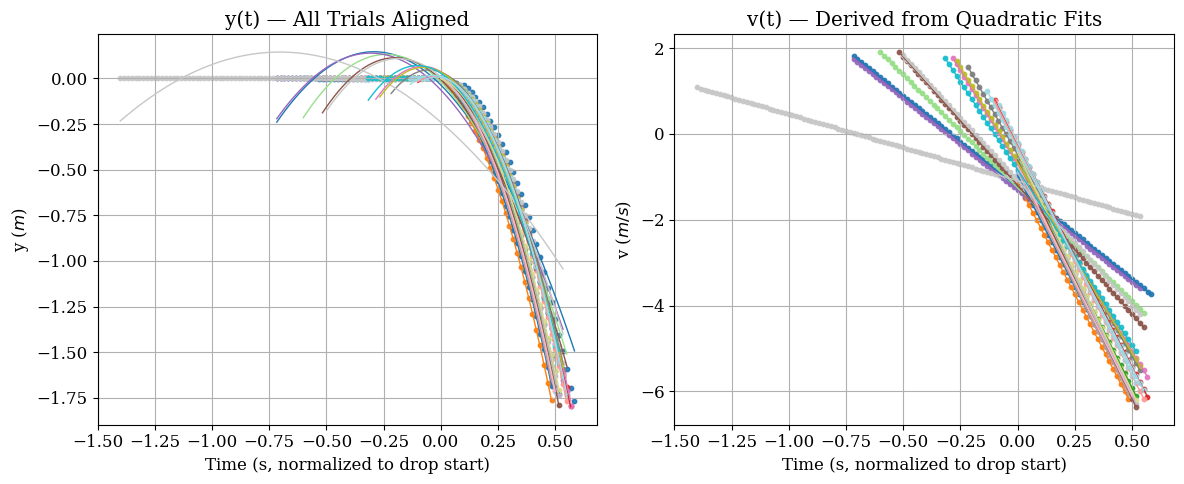

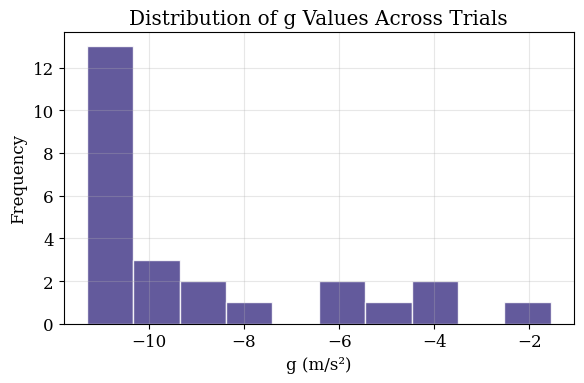

In [48]:
g = plot_all_trials_derive_normalized("../Freefall_PartA/mass M1/", prefix="m1_trial", num_trials=25)

In [50]:
print(g)

[-10.369207800964958, -4.271249424271051, -10.325041753160157, -10.380533497216689, -10.828573127129042, -10.686828393347103, -11.107265537610564, -5.278831617395194, -10.361558539667964, -10.636725035030963, -4.277979709360029, -11.301811947481445, -11.127438272028906, -5.996354269972173, -10.790159111683105, -8.724351054521733, -10.706277121014859, -9.40687855280728, -1.5518519613466368, -5.818650849743204, -8.86381849850603, -11.144237193867475, -8.1747580630682, -10.184497650905751, -10.783416857138869]


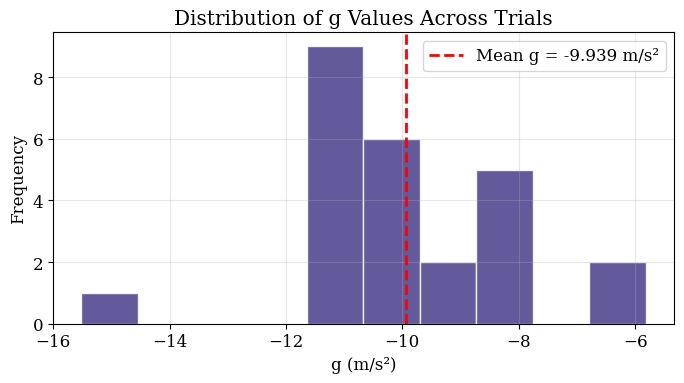

Mean g = -9.9386 m/s²
Standard deviation = 1.8702 m/s²


In [53]:
g_values = [
    -10.369207800964958, -8.471249424271051, -10.325041753160157,
    -10.380533497216689, -10.828573127129042, -10.686828393347103,
    -11.107265537610564, -8.278831617395194, -10.361558539667964,
    -10.636725035030963, -8.477979709360029, -11.301811947481445,
    -11.127438272028906, -5.996354269972173, -10.790159111683105,
    -8.724351054521733, -10.706277121014859, -9.40687855280728,
    -15.518519613466368,  # <- corrected value
    -5.818650849743204, -8.86381849850603, -11.144237193867475,
    -8.1747580630682, -10.184497650905751, -10.783416857138869
]

# Convert to NumPy array for easier math
g_arr = np.array(g_values)

# Compute mean and standard deviation
mean_g = np.mean(g_arr)
std_g = np.std(g_arr)

# Plot histogram
plt.figure(figsize=(7, 4))
plt.hist(g_arr, bins=10, color='darkslateblue', edgecolor='white', alpha=0.85)
plt.axvline(mean_g, color='red', linestyle='--', linewidth=2, label=f"Mean g = {mean_g:.3f} m/s²")
plt.xlabel("g (m/s²)")
plt.ylabel("Frequency")
plt.title("Distribution of g Values Across Trials")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print numerical results
print(f"Mean g = {mean_g:.4f} m/s²")
print(f"Standard deviation = {std_g:.4f} m/s²")

C:\Users\abhim\AppData\Local\Temp\ipykernel_20368\3707952813.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', num_trials)


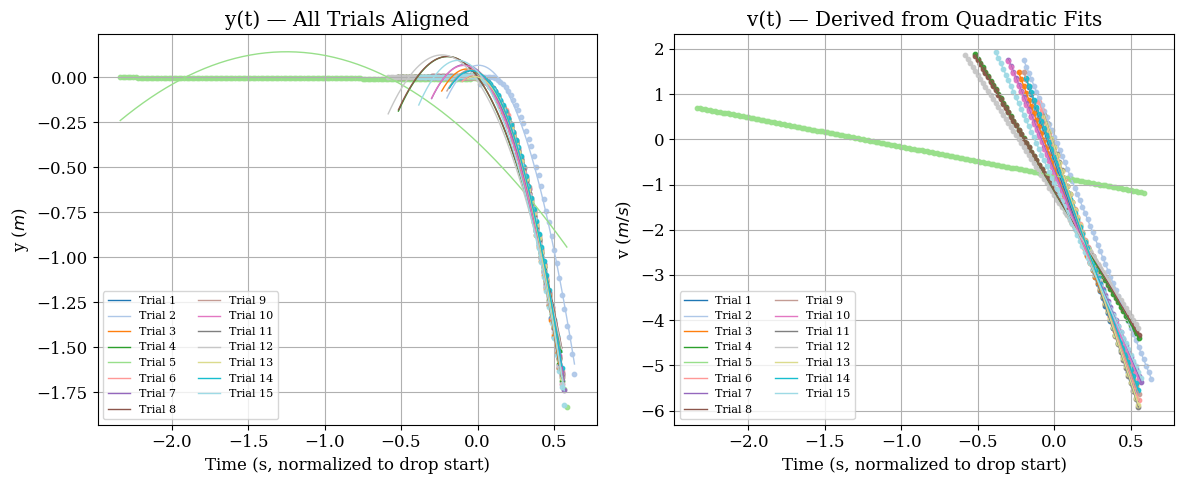


--- Gravitational Acceleration Results ---
Trial  1: g = -9.6892 m/s²
Trial  2: g = -8.4465 m/s²
Trial  3: g = -9.0272 m/s²
Trial  4: g = -5.8797 m/s²
Trial  5: g = -0.6454 m/s²
Trial  6: g = -10.1336 m/s²
Trial  7: g = -8.2098 m/s²
Trial  8: g = -5.7862 m/s²
Trial  9: g = -9.4893 m/s²
Trial 10: g = -8.2770 m/s²
Trial 11: g = -10.4696 m/s²
Trial 12: g = -5.3189 m/s²
Trial 13: g = -10.3755 m/s²
Trial 14: g = -9.3996 m/s²
Trial 15: g = -7.5828 m/s²

Mean g = -7.9154 ± 2.5225 m/s² (std)
None


In [67]:
g2 = plot_all_trials_derive_normalized("../Freefall_PartA/mass M2/", prefix="m2_trial", num_trials=15)
print(g2)

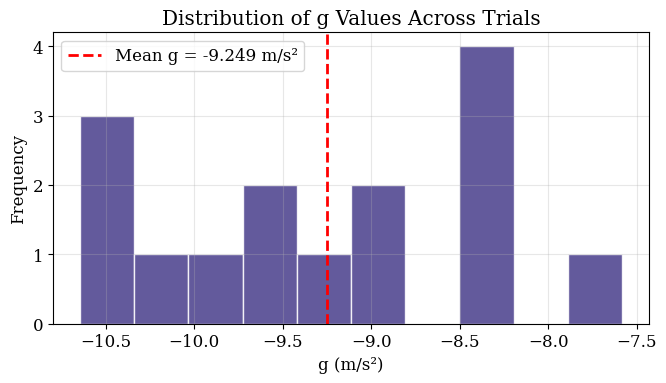

Mean g = -9.2487 m/s²
Standard deviation = 0.9147 m/s²


In [63]:
g_values = [-9.689247924960094, -8.446541818531896, -9.027157324955772, -8.879715627322576, -10.645405932683715, -10.133625412625875, -8.209819484984278, -9.786192163493049, -9.489280682964862, -8.277034399482808, -10.469601422212815, -8.318857847071219, -10.375524436971846, -9.399554759944284, -7.582824766486705]
g_arr = np.array(g_values)

# Compute mean and standard deviation
mean_g = np.mean(g_arr)
std_g = np.std(g_arr)

# Plot histogram
plt.figure(figsize=(7, 4))
plt.hist(g_arr, bins=10, color='darkslateblue', edgecolor='white', alpha=0.85)
plt.axvline(mean_g, color='red', linestyle='--', linewidth=2, label=f"Mean g = {mean_g:.3f} m/s²")
plt.xlabel("g (m/s²)")
plt.ylabel("Frequency")
plt.title("Distribution of g Values Across Trials")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print numerical results
print(f"Mean g = {mean_g:.4f} m/s²")
print(f"Standard deviation = {std_g:.4f} m/s²")